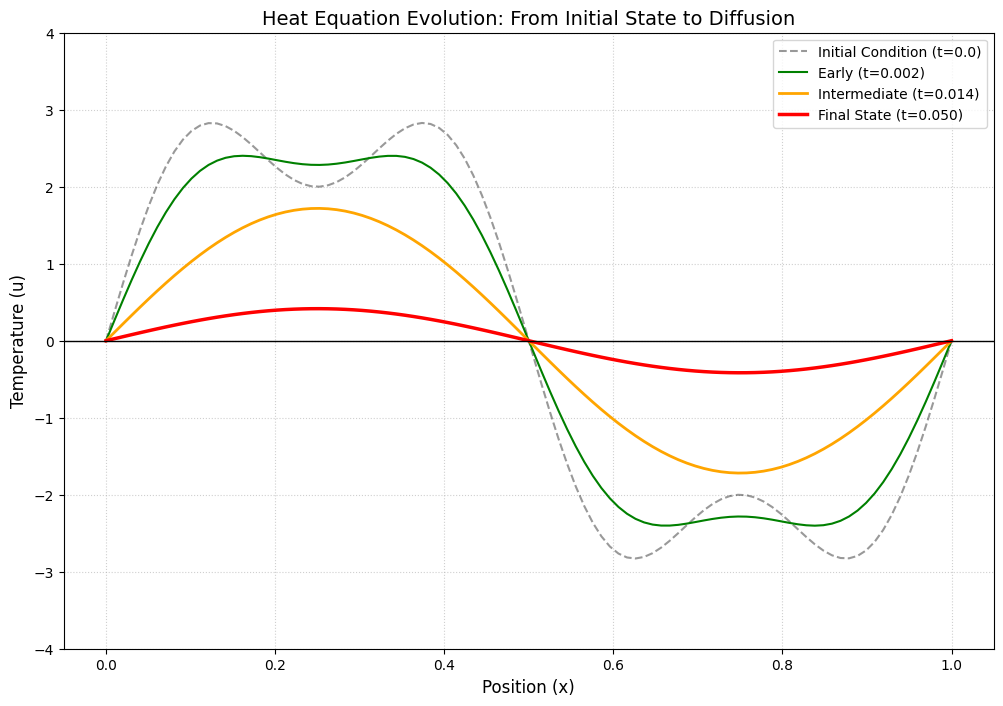

Timeline plot generated and saved!


In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from petsc4py import PETSc

# 1. Path Setup
project_path = "/home/megans/ma402_project"
if project_path not in sys.path:
    sys.path.append(project_path)
from MA402_Final_Project import Heat1D

# 2. Setup Solver
m = 100
model = Heat1D(m=m)
model.form_rhs_matrix()
x_coords = np.linspace(0, 1, m)

def get_solution_at_time(target_time):
    if target_time == 0:
        model.initial_condition(model.u)
        return model.u.getArray().copy(), 0.0
    
    model.initial_condition(model.u)
    ts = PETSc.TS().create()
    ts.setProblemType(ts.ProblemType.LINEAR)
    ts.setRHSFunction(model.rhs_function)
    ts.setRHSJacobian(model.A, model.A)
    ts.setTimeStep(model.h * model.h / 2.0)
    ts.setMaxTime(target_time)
    ts.setExactFinalTime(ts.ExactFinalTime.MATCHSTEP)
    ts.solve(model.u)
    return model.u.getArray().copy(), ts.getTime()

# 3. Get results for the different times to show how the heat equation acts over time
u_zero, t0  = get_solution_at_time(0.0)    # THE START
u_early, t1 = get_solution_at_time(0.002)  # Just started (Molar shape)
u_orig, t2  = get_solution_at_time(0.014)  # Middle ground
u_final, t3 = get_solution_at_time(0.050)  # Flattening out

# 4. Plotting
plt.figure(figsize=(12, 8))

# Plotting the timeline
plt.plot(x_coords, u_zero,  'k--', label=f'Initial Condition (t={t0:.1f})', alpha=0.4)
plt.plot(x_coords, u_early, 'g-',  label=f'Early (t={t1:.3f})', linewidth=1.5)
plt.plot(x_coords, u_orig,  'orange', label=f'Intermediate (t={t2:.3f})', linewidth=2)
plt.plot(x_coords, u_final, 'r-',   label=f'Final State (t={t3:.3f})', linewidth=2.5)

# Formatting
plt.axhline(0, color='black', linewidth=1)
plt.ylim(-4, 4) 
plt.title("Heat Equation Evolution: From Initial State to Diffusion", fontsize=14)
plt.xlabel("Position (x)", fontsize=12)
plt.ylabel("Temperature (u)", fontsize=12)
plt.legend(loc='upper right', frameon=True)
plt.grid(True, which='both', linestyle=':', alpha=0.6)

plt.savefig('heat_diffusion_complete_timeline.png', dpi=300)
plt.show()

print("Timeline plot generated and saved!")